<a href="https://colab.research.google.com/github/DarkLyng/Proyecto_Modelos/blob/main/Proyecto_Modelos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Preparar datos**

In [1]:
# Bibliotecas de Python

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import csv

warnings.filterwarnings('ignore')

In [2]:
# Carga el archivo xlsx
xls = pd.ExcelFile("/content/Contoso Sales.xlsx")
print(xls.sheet_names)

['DimChannel', 'DimGeography', 'DimProduct', 'DimProductCategory', 'DimProductSubCategory', 'DimPromotion', 'DimStores']


In [3]:
# Crea una lista con los nombres de las hojas de Contoso Sales
tabs = ['DimChannel', 'DimGeography', 'DimProduct', 'DimProductCategory', 'DimProductSubCategory', 'DimPromotion', 'DimStores']
tablas = []

In [4]:
# Se agrega en la lista los nombres de las hojas del xlsx
for tab in tabs:
  df = pd.read_excel("/content/Contoso Sales.xlsx", sheet_name=tab,)
  tablas.append(df)

In [5]:
# Lee el el archivo FactSales, lo separa y agrega a la lista "tablas" los datos del txt
ventas = pd.read_csv("FactSales.txt", sep="\t")
tablas.append(ventas)

In [6]:
# Muestra la cantidad de tablas que se cargaron a la lista
print(f"Total de tablas cargadas en la lista: {len(tablas)}")

Total de tablas cargadas en la lista: 8


In [7]:
#print(tablas)

# **2. Transformación**

In [8]:
# Es una prueba para revisar la información
#tablas[1]

Se crean 7 dataframes diferentes con los datos, el de df_ventas es de los más importantes porque es el que contiene toda la información de FactSales.txt.

In [9]:
df_channel = tablas[0]        # Índice 0: Canal
df_geography = tablas[1]      # Índice 1: Geografía
df_product= tablas[2]         # Índice 2: Productos
df_productcat = tablas[3]     # Índice 3: Categoría de Productos
df_productsubcat = tablas[4]  # Índice 4: Subcategoría de Productos
df_promotion = tablas[5]      # Índice 5: Promociones
df_stores = tablas[6]         # Índice 0: Tiendas
df_ventas = tablas[-1]        # Último índice

Cambiar dtype de ciertas columnas de df_ventas

In [10]:
df_ventas['DateKey'] = pd.to_datetime(df_ventas['DateKey'], errors='coerce')

In [11]:
df_ventas['ReturnQuantity'] = pd.to_numeric(df_ventas['ReturnQuantity'], errors='coerce').fillna(0).astype(int)

In [12]:
df_ventas['Cantidad_total'] = pd.to_numeric(df_ventas['Cantidad_total'], errors='coerce').fillna(0).astype(int)

In [13]:
df_ventas['Precio_unitario'] = pd.to_numeric(df_ventas['Precio_unitario'], errors='coerce').fillna(0).astype(float)

In [14]:
df_ventas['Ingresos'] = pd.to_numeric(df_ventas['Ingresos'], errors='coerce').fillna(0).astype(float)

Métricas de las Tablas FactSales

In [15]:
cantidad_ventas = df_ventas['SalesQuantity'].sum()
print(f" Cantidad total de ventas (Unidades): {cantidad_ventas:.0f}")

 Cantidad total de ventas (Unidades): 2191230


In [16]:
cantidad_devoluciones = df_ventas['ReturnQuantity'].sum()
print(f" Cantidad total de devoluciones (Unidades): {cantidad_devoluciones:.0f}")

 Cantidad total de devoluciones (Unidades): 0


In [17]:
cantidad_total = cantidad_ventas - cantidad_devoluciones
print(f" Cantidad total de ventas menos devoluciones (Cantidad Total): {cantidad_total:.0f}")

 Cantidad total de ventas menos devoluciones (Cantidad Total): 2191230


Otras Métricas

In [18]:
promedio_precio_unitario = df_product['UnitPrice'].mean()
print(f" Promedio precio unitario: ₡{promedio_precio_unitario:.2f}")

 Promedio precio unitario: ₡316.92


In [19]:
numero_stores = df_stores['StoreKey'].count()
print(f" Número total de tiendas registradas: {numero_stores:}")

 Número total de tiendas registradas: 310


In [20]:
numero_stores_con_ventas = df_ventas['StoreKey'].nunique()
print(f" Número de tiendas con ventas reales: {numero_stores_con_ventas:,}")

 Número de tiendas con ventas reales: 305


In [21]:
numero_ordenes = len(df_ventas)
print(f" Número total de ordenes procesadas: {numero_ordenes:}")

 Número total de ordenes procesadas: 240576


In [22]:
numero_ordenes_con_devolucion = len(df_ventas[df_ventas['ReturnQuantity'] > 0])
print(f" Ordenes con devolución: {numero_ordenes_con_devolucion:}")

 Ordenes con devolución: 0


In [23]:
total_ingresos = df_ventas['Ingresos'].sum()
print(f" Total de ingresos históricos: ₡{total_ingresos:.2f}")

 Total de ingresos históricos: ₡18385201.00


# **3. Carga**

In [24]:
# Comproba por separado el número de columnas y filas del dataframe
tablas[2].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1690 entries, 0 to 1689
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ProductKey             1690 non-null   int64  
 1   ProductName            1690 non-null   object 
 2   ProductDescription     1690 non-null   object 
 3   ProductSubcategoryKey  1690 non-null   int64  
 4   Manufacturer           1690 non-null   object 
 5   BrandName              1690 non-null   object 
 6   ClassID                1690 non-null   int64  
 7   ClassName              1690 non-null   object 
 8   ColorID                1690 non-null   int64  
 9   ColorName              1690 non-null   object 
 10  Size                   1240 non-null   object 
 11  Weight                 1526 non-null   float64
 12  UnitCost               1690 non-null   float64
 13  UnitPrice              1690 non-null   float64
dtypes: float64(3), int64(4), object(7)
memory usage: 185.0+ 

In [25]:
# Muestra la cantidad de filas columnas y datos faltantes del dataframe
print(" Conteo de filas, columnas y datos fantantes \n")

for i, df in enumerate(tablas):
    # Filas y columnas
    filas = df.shape[0]
    columnas = df.shape[1]
    # Total de celdas vacías o con errores en toda la tabla
    celdas_vacias_tot = df.isnull().sum().sum()

    # Nombre original usando la lista tabs
    nombre_tabla = tabs[i] if i < len(tabs) else "FactSales"
    print(f"Índice [{i}] - Tabla: '{nombre_tabla}'")
    print(f" Filas: {filas}")
    print(f" Columnas: {columnas}")
    print(f" Total de celdas vacías o errores encontrados: {celdas_vacias_tot}")
    print("-" * 40)

 Conteo de filas, columnas y datos fantantes 

Índice [0] - Tabla: 'DimChannel'
 Filas: 4
 Columnas: 2
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [1] - Tabla: 'DimGeography'
 Filas: 674
 Columnas: 3
 Total de celdas vacías o errores encontrados: 3
----------------------------------------
Índice [2] - Tabla: 'DimProduct'
 Filas: 1690
 Columnas: 14
 Total de celdas vacías o errores encontrados: 614
----------------------------------------
Índice [3] - Tabla: 'DimProductCategory'
 Filas: 8
 Columnas: 2
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [4] - Tabla: 'DimProductSubCategory'
 Filas: 44
 Columnas: 3
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [5] - Tabla: 'DimPromotion'
 Filas: 28
 Columnas: 7
 Total de celdas vacías o errores encontrados: 0
----------------------------------------
Índice [6] - Tabla: 'DimStores'
 Filas: 310


In [26]:
# Función que permite obtener un análisis estadístico de cada hoja de Contoso Sales

def analizar_tabla_lista(df, nombre_tabla):
    print(f"Análisis de la tabla: {nombre_tabla}")

    for col in df.columns:
        dtype = df[col].dtype
        total_valores = len(df[col])
        valores_unicos = df[col].nunique()
        faltantes = df[col].isnull().sum()

        print(f"\n Columna: '{col}' | Tipo: {dtype}")
        print(f"  - Datos faltantes: {faltantes} ({ (faltantes/total_valores)*100:.2f}%)")
        print(f"  - Cardinalidad (Valores únicos): {valores_unicos}")

        es_identificador = col.endswith('Key') or col.endswith('ID')

        # Variables numéricas continuas o cuantitativas
        if np.issubdtype(dtype, np.number) and valores_unicos > 10 and not es_identificador:
            print("  - Clasificación: Variable numérica continua")

            media = df[col].mean()
            q1 = df[col].quantile(0.25)   # Primer Cuartil (25%)
            mediana = df[col].median()
            q3 = df[col].quantile(0.75)   # Tercer Cuartil (75%)
            desv_est = df[col].std()
            varianza = df[col].var()
            inclinacion = df[col].skew()  # Inclinación(Skewness)
            curtosis = df[col].kurt()     # Kurtosis
            val_min = df[col].min()
            val_max = df[col].max()
            # Cálculo de los outliers
            ric = q3 - q1
            limite_inferior_outlier = q1 - 1.5 * ric
            limite_superior_outlier = q3 + 1.5 * ric

            print(f"  - Valor esperado (Media): {media:.4f}")
            print(f"  - Cuartil 1 (Q1 - 25%): {q1:.4f}")
            print(f"  - Mediana: {mediana:.4f}")
            print(f"  - Cuartil 3 (Q3 - 75%): {q3:.4f}")
            print(f"  - Varianza: {varianza:.4f}")
            print(f"  - Desviación estándar: {desv_est:.4f}")
            print(f"  - Inclinación (Skewness): {inclinacion:.4f}")
            print(f"  - Kurtosis: {curtosis:.4f}")

            if abs(inclinacion) < 0.5:
                  print("  -  Distribución simétrica.")
            else:
                print(f"  - Distribución asimétrica a la {'derecha' if inclinacion > 0 else 'izquierda'}.")

            print(f"  - Valor mínimo: {val_min:.4f}")
            print(f"  - Valor máximo: {val_max:.4f}")
            print(f"  - Rango intercuartílico (RIC): {ric:.4f}")
            print(f"  - Límites para outliers: [{limite_inferior_outlier:.2f} , {limite_superior_outlier:.2f}]")

        # Variables discretas o cualitativas (Frecuencia y probabilidad empírica)
        else:
            print("  - Clasificación: Variable cualitativa o discreta (Atributo/Llave)")
            frecuencias = df[col].value_counts(dropna=False).head(5)
            probabilidades = df[col].value_counts(dropna=False, normalize=True).head(5)

            print("  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):")
            for val, freq in frecuencias.items():
                prob = probabilidades[val]
                print(f"     Valor: {val} | Frecuencia: {freq} | Probabilidad: {prob:.4f} ({prob*100:.2f}%)")



In [27]:
# Se analiza por índices
# Analiza la tabla DimChannel
analizar_tabla_lista(tablas[0], "DimChannel")


Análisis de la tabla: DimChannel

 Columna: 'ChannelKey' | Tipo: int64
  - Datos faltantes: 0 (0.00%)
  - Cardinalidad (Valores únicos): 4
  - Clasificación: Variable cualitativa o discreta (Atributo/Llave)
  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):
     Valor: 1 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: 2 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: 3 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: 4 | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)

 Columna: 'ChannelName' | Tipo: object
  - Datos faltantes: 0 (0.00%)
  - Cardinalidad (Valores únicos): 4
  - Clasificación: Variable cualitativa o discreta (Atributo/Llave)
  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):
     Valor: Store | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: Online | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: Catalog | Frecuencia: 1 | Probabilidad: 0.2500 (25.00%)
     Valor: Reseller | Fre

In [28]:
# Analiza la tabla DimGeography
#analizar_tabla_lista(tablas[1], "DimGeography")

In [29]:
# Analiza la tabla DimProduct
#analizar_tabla_lista(tablas[2], "DimProduct")

In [30]:
# Analiza la tabla DimProductCategory
#analizar_tabla_lista(tablas[3], "DimProductCategory")

In [31]:
# Analiza la tabla DimProductSubCategory
#analizar_tabla_lista(tablas[4], "DimProductSubCategory")

In [32]:
# Analiza la tabla DimPromotion
#analizar_tabla_lista(tablas[5], "DimPromotion")

In [33]:
# Analiza la tabla DimStores
#analizar_tabla_lista(tablas[6], "DimStores")

In [34]:
# Analiza la tabla FactSales (Último índice de la lista)
analizar_tabla_lista(tablas[-1], "FactSales")

Análisis de la tabla: FactSales

 Columna: 'OrderID' | Tipo: int64
  - Datos faltantes: 0 (0.00%)
  - Cardinalidad (Valores únicos): 240576
  - Clasificación: Variable cualitativa o discreta (Atributo/Llave)
  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):
     Valor: 986719 | Frecuencia: 1 | Probabilidad: 0.0000 (0.00%)
     Valor: 970646 | Frecuencia: 1 | Probabilidad: 0.0000 (0.00%)
     Valor: 963048 | Frecuencia: 1 | Probabilidad: 0.0000 (0.00%)
     Valor: 962206 | Frecuencia: 1 | Probabilidad: 0.0000 (0.00%)
     Valor: 960576 | Frecuencia: 1 | Probabilidad: 0.0000 (0.00%)

 Columna: 'DateKey' | Tipo: datetime64[ns]
  - Datos faltantes: 1 (0.00%)
  - Cardinalidad (Valores únicos): 642
  - Clasificación: Variable cualitativa o discreta (Atributo/Llave)
  - Los 5 valores con mayor frecuencia y probabilidad empírica P(X=x):
     Valor: 2007-06-25 00:00:00 | Frecuencia: 1041 | Probabilidad: 0.0043 (0.43%)
     Valor: 2007-06-19 00:00:00 | Frecuencia: 1024 | Pro

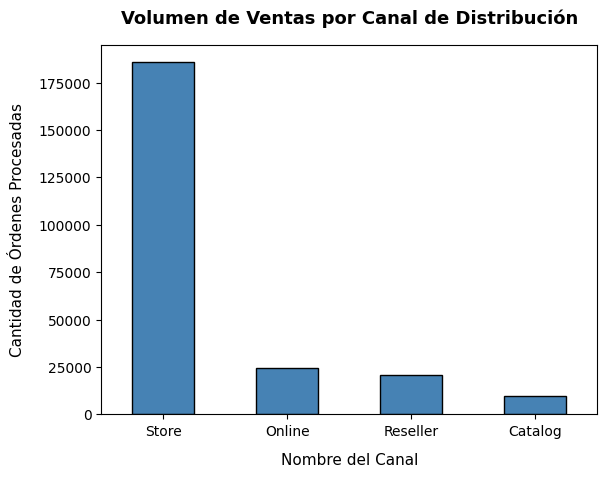

In [59]:
# Crear un diccionario para traducir códigos a nombres
mapa_canales = dict(zip(tablas[0]['ChannelKey'], tablas[0]['ChannelName']))

# Traducir los datos y contar frecuencias
ventas_por_canal = tablas[7]['channelKey'].map(mapa_canales).value_counts()

# Gráfico
ventas_por_canal.plot(kind='bar', color='steelblue', edgecolor='black', rot=0)
plt.title("Volumen de Ventas por Canal de Distribución", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Nombre del Canal", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Órdenes Procesadas", fontsize=11, labelpad=10)
plt.show()

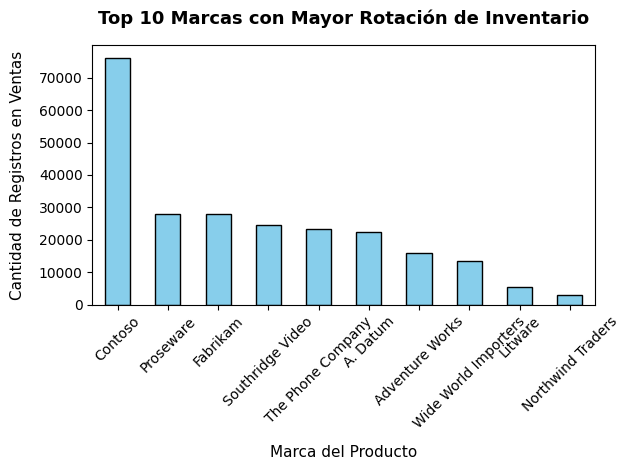

In [60]:
# Unir temporalmente para obtener la marca del producto vendido
df_marcas = tablas[7].merge(tablas[2][['ProductKey', 'BrandName']], on='ProductKey', how='left')
top_marcas = df_marcas['BrandName'].value_counts().head(10)

# Gráfico
top_marcas.plot(kind='bar', color='skyblue', edgecolor='black', rot=45)
plt.title("Top 10 Marcas con Mayor Rotación de Inventario", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Marca del Producto", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Registros en Ventas", fontsize=11, labelpad=10)
plt.tight_layout() # Evita que se corten las etiquetas inclinadas
plt.show()

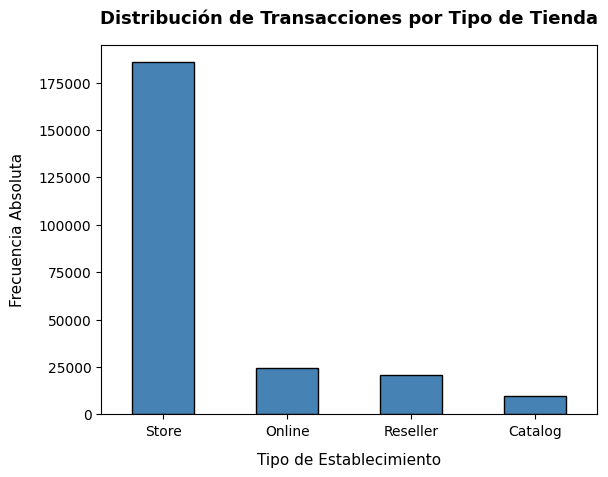

In [61]:
# Nota: Cambiar 'StoreType' por el nombre exacto de la columna en tablas[6] si varía (ej: 'StoreName')
mapa_tiendas = dict(zip(tablas[6]['StoreKey'], tablas[6]['StoreType']))

ventas_por_tipo_tienda = tablas[7]['StoreKey'].map(mapa_tiendas).value_counts()

ventas_por_tipo_tienda.plot(kind='bar', color='steelblue', edgecolor='black', rot=0)
plt.title("Distribución de Transacciones por Tipo de Tienda", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Tipo de Establecimiento", fontsize=11, labelpad=10)
plt.ylabel("Frecuencia Absoluta", fontsize=11, labelpad=10)
plt.show()

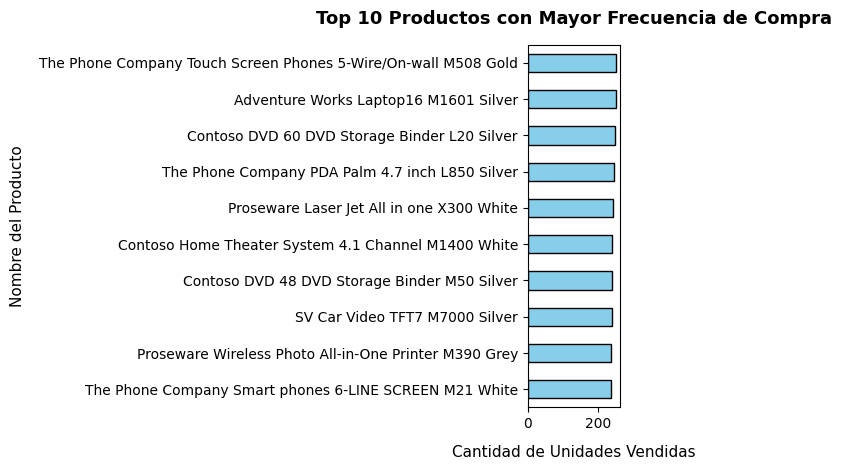

In [62]:
mapa_productos = dict(zip(tablas[2]['ProductKey'], tablas[2]['ProductName']))

top_nombres_productos = tablas[7]['ProductKey'].map(mapa_productos).value_counts().head(10)

top_nombres_productos.plot(kind='barh', color='skyblue', edgecolor='black') # Gráfico horizontal para leer mejor nombres largos
plt.title("Top 10 Productos con Mayor Frecuencia de Compra", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Cantidad de Unidades Vendidas", fontsize=11, labelpad=10)
plt.ylabel("Nombre del Producto", fontsize=11, labelpad=10)
plt.gca().invert_yaxis() # Pone el #1 arriba
plt.tight_layout()
plt.show()

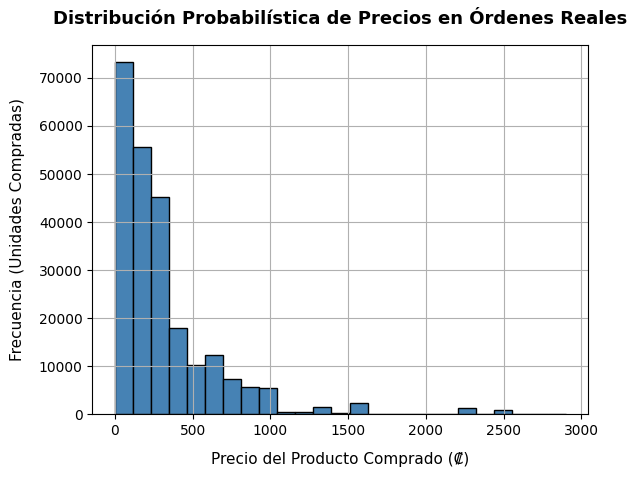

In [63]:
# Mapeamos el precio unitario del catálogo a cada transacción de ventas
mapa_precios = dict(zip(tablas[2]['ProductKey'], tablas[2]['UnitPrice']))
precios_transacciones = tablas[7]['ProductKey'].map(mapa_precios)

# Gráfico
precios_transacciones.hist(bins=25, color='steelblue', edgecolor='black')
plt.title("Distribución Probabilística de Precios en Órdenes Reales", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Precio del Producto Comprado (₡)", fontsize=11, labelpad=10)
plt.ylabel("Frecuencia (Unidades Compradas)", fontsize=11, labelpad=10)
plt.show()

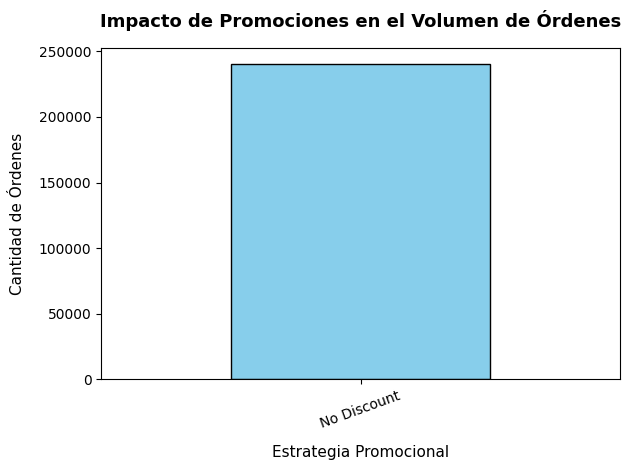

In [64]:
# Nota: Ajustar 'PromotionName' según se llame en tablas[5]
mapa_promo = dict(zip(tablas[5]['PromotionKey'], tablas[5]['PromotionName']))

ventas_promo = tablas[7]['PromotionKey'].map(mapa_promo).value_counts().head(5)

ventas_promo.plot(kind='bar', color='skyblue', edgecolor='black', rot=20)
plt.title("Impacto de Promociones en el Volumen de Órdenes", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Estrategia Promocional", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Órdenes", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

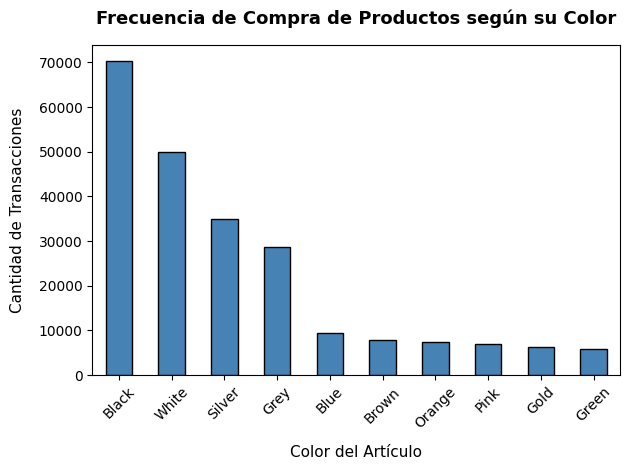

In [65]:
mapa_colores = dict(zip(tablas[2]['ProductKey'], tablas[2]['ColorName']))

ventas_colores = tablas[7]['ProductKey'].map(mapa_colores).value_counts().head(10)

ventas_colores.plot(kind='bar', color='steelblue', edgecolor='black', rot=45)
plt.title("Frecuencia de Compra de Productos según su Color", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Color del Artículo", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Transacciones", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

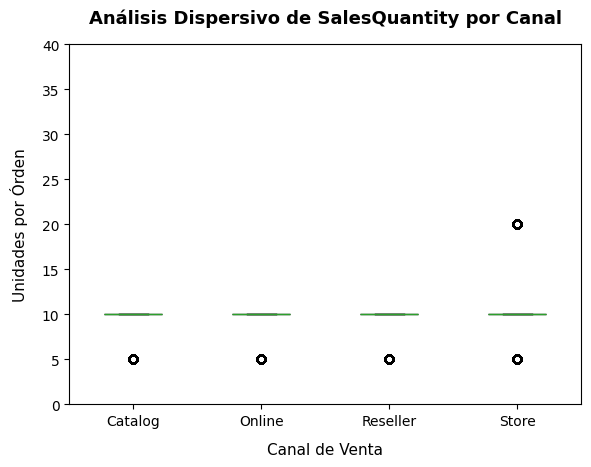

In [66]:
# Combinamos ventas con nombres de canal
df_cajas = tablas[7].merge(tablas[0][['ChannelKey', 'ChannelName']], left_on='channelKey', right_on='ChannelKey', how='left')

# Graficar múltiples boxplots agrupados por canal usando el formato estándar
df_cajas.boxplot(column='SalesQuantity', by='ChannelName', grid=False,
                 patch_artist=True, boxprops=dict(facecolor='skyblue', color='black'))

plt.title("Análisis Dispersivo de SalesQuantity por Canal", fontsize=13, fontweight='bold', pad=15)
plt.suptitle("") # Remueve el título automático feo de pandas
plt.xlabel("Canal de Venta", fontsize=11, labelpad=10)
plt.ylabel("Unidades por Órden", fontsize=11, labelpad=10)
plt.ylim(0, 40) # Ajustamos el límite vertical para apreciar bien las cajas sin los outliers masivos
plt.show()

In [67]:
# Nota: Ajustar 'Status' o columna correspondiente en tablas[6]
mapa_status = dict(zip(tablas[6]['StoreKey'], tablas[6]['Status']))

ventas_status = tablas[7]['StoreKey'].map(mapa_status).value_counts()

ventas_status.plot(kind='bar', color='steelblue', edgecolor='black', rot=0)
plt.title("Estado Operativo de Tiendas vs Cantidad de Transacciones", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Estado de la Sucursal (Status)", fontsize=11, labelpad=10)
plt.ylabel("Órdenes Procesadas", fontsize=11, labelpad=10)
plt.show()

KeyError: 'Status'

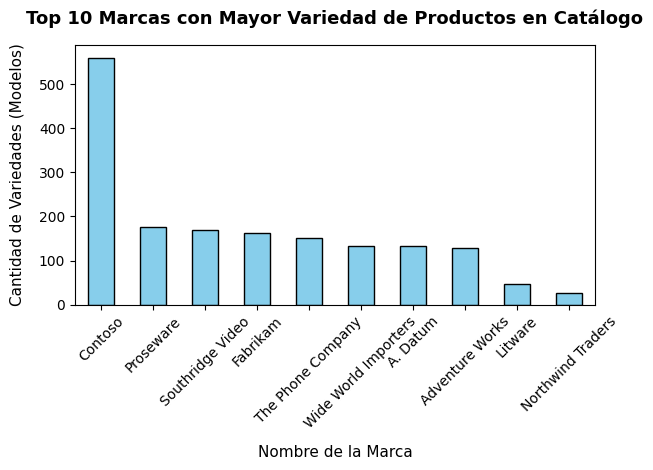

In [68]:
variedad_marcas = tablas[2]['BrandName'].value_counts().head(10)

variedad_marcas.plot(kind='bar', color='skyblue', edgecolor='black', rot=45)
plt.title("Top 10 Marcas con Mayor Variedad de Productos en Catálogo", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Nombre de la Marca", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Variedades (Modelos)", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

In [36]:
# Otra forma de obtener los valores atípicos, limites, cuartiles, etc
#print(tablas[7]["SalesQuantity"].describe())

In [37]:
#tablas[7]["SalesQuantity"].plot.kde()
#plt.xlim([0,50])

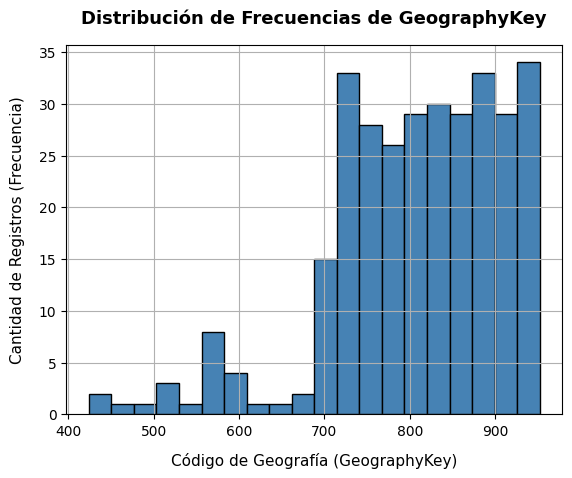

In [38]:
# Histograma
tablas[6]["GeographyKey"].hist(bins=20, color='steelblue', edgecolor='black')

# Etiquetas de los ejes y el título
plt.title("Distribución de Frecuencias de GeographyKey", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Código de Geografía (GeographyKey)", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Registros (Frecuencia)", fontsize=11, labelpad=10)

plt.show()

<Axes: >

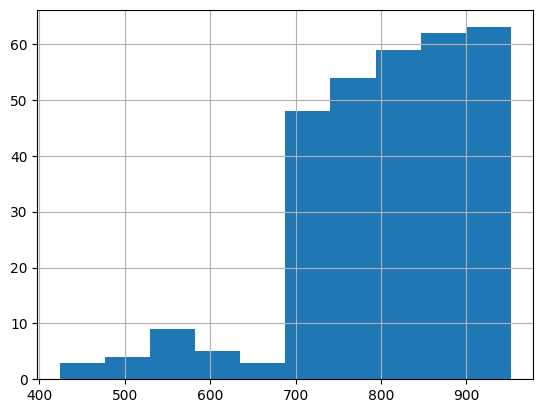

In [39]:
tablas[6]["GeographyKey"].hist()

In [40]:
df_ventas.to_csv('FactSales_Procesado.csv', index=False, sep=";")

In [41]:
#files.download('FactSales_Procesado.csv')